<a href="https://colab.research.google.com/github/sandip-thakuri01/Data-Science-Projects/blob/main/Text_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import re
import string
import unicodedata
from html import unescape
from collections import Counter

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from wordcloud import WordCloud


import nltk

for _pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    nltk.download(_pkg, quiet=True)

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

print(" All imports successful.")

 All imports successful.


Load Datasets


In [5]:
def load_dataset(filepath: str, nrows: int = 5000) -> pd.DataFrame:

    df = pd.read_csv(
        filepath,
        encoding="utf-8",
        on_bad_lines="skip",
        nrows=nrows,
    )
    print(f"Loaded {len(df):,} rows | Columns: {df.columns.tolist()}")
    return df

In [6]:
df_questions = load_dataset(filepath="/content/Questions.csv", nrows=5000)
df_answers   = load_dataset(filepath="/content/Answers.csv",   nrows=5000)
df_tags      = load_dataset(filepath="/content/Tags.csv",      nrows=5000)

display(df_questions.head())

Loaded 5,000 rows | Columns: ['Id', 'OwnerUserId', 'CreationDate', 'ClosedDate', 'Score', 'Title', 'Body']
Loaded 5,000 rows | Columns: ['Id', 'OwnerUserId', 'CreationDate', 'ParentId', 'Score', 'Body']
Loaded 5,000 rows | Columns: ['Id', 'Tag']


,Id,OwnerUserId,CreationDate,ClosedDate,Score,Title,Body
0,80,26.0,2008-08-01T13:57:07Z,NaN,26,SQLStatement.execute() - multiple queries in o...,<p>I've written a database generation script i...
1,90,58.0,2008-08-01T14:41:24Z,2012-12-26T03:45:49Z,144,Good branching and merging tutorials for Torto...,<p>Are there any really good tutorials explain...
2,120,83.0,2008-08-01T15:50:08Z,NaN,21,ASP.NET Site Maps,<p>Has anyone got experience creating <strong>...
3,180,2089740.0,2008-08-01T18:42:19Z,NaN,53,Function for creating color wheels,<p>This is something I've pseudo-solved many t...
4,260,91.0,2008-08-01T23:22:08Z,NaN,49,Adding scripting functionality to .NET applica...,<p>I have a little game written in C#. It uses...


Texst Extraction


In [7]:
def extract_text(df: pd.DataFrame) -> pd.DataFrame:
    """Combine Title + Body into a single 'raw_text' column."""
    df = df.copy()
    df["Title"] = df["Title"].fillna("") if "Title" in df.columns else ""
    df["Body"]  = df["Body"].fillna("")  if "Body"  in df.columns else ""
    df["raw_text"] = df["Title"] + " " + df["Body"]
    return df

Cleaning Functions

In [8]:
# ── 4a. HTML removal ────────────────────────────────────────
def remove_html(text: str) -> str:
    """Strip HTML tags and decode HTML entities (e.g. &amp; → &)."""
    text = unescape(text)
    text = re.sub(r"<code>.*?</code>", " ", text, flags=re.DOTALL)
    text = re.sub(r"<pre>.*?</pre>",  " ", text, flags=re.DOTALL)
    text = re.sub(r"<[^>]+>", " ", text)
    return text

# ── 4b. Unicode normalization ───────────────────────────────
def normalize_unicode(text: str) -> str:
    """NFKD normalization → drop non-ASCII characters."""
    text = unicodedata.normalize("NFKD", text)
    text = text.encode("ascii", "ignore").decode("ascii")
    return text

# ── 4c. URL & email replacement ─────────────────────────────
URL_PATTERN   = re.compile(r"https?://\S+|www\.\S+")
EMAIL_PATTERN = re.compile(r"\S+@\S+\.\S+")

def remove_urls_emails(text: str) -> str:
    text = URL_PATTERN.sub(" <URL> ", text)
    text = EMAIL_PATTERN.sub(" <EMAIL> ", text)
    return text

# ── 4d. Special characters ──────────────────────────────────
def clean_special_chars(text: str, keep_programming_symbols: bool = True) -> str:
    """
    Remove noise characters while optionally retaining
    programming-relevant symbols: # (C#), _ (snake_case), @ (decorators).
    """
    if keep_programming_symbols:
        text = re.sub(r"[^a-zA-Z0-9\s_#@\.\+\-]", " ", text)
    else:
        text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    return text

# ── 4e. Whitespace collapse ──────────────────────────────────
def remove_extra_whitespace(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()

# ── 4f. Lowercasing ─────────────────────────────────────────
def to_lowercase(text: str) -> str:
    return text.lower()

Tokenization

In [9]:
def word_tokenize_text(text: str) -> list:
    """Word-level tokenization via NLTK."""
    return word_tokenize(text)

def sentence_tokenize_text(text: str) -> list:
    """Sentence-level tokenization via NLTK."""
    return sent_tokenize(text)

def whitespace_tokenize(text: str) -> list:
    """Fast whitespace-based tokenizer (no external dependency)."""
    return text.split()

Stopword Removal

In [10]:
STOP_WORDS = set(stopwords.words("english"))

# StackOverflow-specific noise words
CUSTOM_STOPWORDS = {
    "using", "use", "used", "want", "need", "know", "like",
    "get", "code", "file", "also", "one", "would", "could",
    "please", "help", "thanks", "thank", "anyone",
}
STOP_WORDS.update(CUSTOM_STOPWORDS)

def remove_stopwords(tokens: list) -> list:
    return [t for t in tokens if t not in STOP_WORDS]

Stemming and Lemmatization

In [11]:
_stemmer    = PorterStemmer()
_lemmatizer = WordNetLemmatizer()

def stem_tokens(tokens: list) -> list:
    """Porter stemming — aggressive but fast."""
    return [_stemmer.stem(t) for t in tokens]

def lemmatize_tokens(tokens: list) -> list:
    """WordNet lemmatization — slower but produces real words."""
    return [_lemmatizer.lemmatize(t) for t in tokens]

Token Filtering


In [12]:
def filter_token_length(tokens: list, min_len: int = 2, max_len: int = 40) -> list:
    """Drop tokens that are too short or suspiciously long."""
    return [t for t in tokens if min_len <= len(t) <= max_len]

# FIX: Changed .isdigit() → .isnumeric() for broader numeric coverage
# (handles superscripts, fractions, etc.)
def remove_numeric_tokens(tokens: list) -> list:
    """Remove purely numeric tokens (line numbers, IDs, etc.)."""
    return [t for t in tokens if not t.isnumeric()]

Full Pipeline


In [13]:
def full_clean_pipeline(
    text: str,
    lowercase: bool     = True,
    remove_stops: bool  = True,
    use_lemmatize: bool = True,
    use_stemming: bool  = False,
) -> dict:
    """
    End-to-end cleaning & normalization pipeline.
    Returns a dict containing every intermediate stage
    plus 'final_tokens' and 'final_text'.
    """
    stages = {}

    stages["01_raw"]           = text
    stages["02_html_removed"]  = remove_html(text)
    stages["03_unicode_norm"]  = normalize_unicode(stages["02_html_removed"])
    stages["04_urls_emails"]   = remove_urls_emails(stages["03_unicode_norm"])
    stages["05_special_chars"] = clean_special_chars(stages["04_urls_emails"])
    stages["06_whitespace"]    = remove_extra_whitespace(stages["05_special_chars"])
    stages["07_lowercase"]     = to_lowercase(stages["06_whitespace"]) if lowercase else stages["06_whitespace"]

    tokens = word_tokenize_text(stages["07_lowercase"])
    stages["08_tokens"] = tokens

    if remove_stops:
        tokens = remove_stopwords(tokens)
    stages["09_no_stopwords"] = tokens

    tokens = filter_token_length(tokens)
    tokens = remove_numeric_tokens(tokens)
    stages["10_filtered"] = tokens

    if use_lemmatize:
        tokens = lemmatize_tokens(tokens)
        stages["11_lemmatized"] = tokens
    elif use_stemming:
        tokens = stem_tokens(tokens)
        stages["11_stemmed"] = tokens
    else:
        stages["11_no_morph"] = tokens

    stages["final_tokens"] = tokens
    stages["final_text"]   = " ".join(tokens)

    return stages

Vocabulary and statistics Helpers


In [14]:
def build_vocabulary(df: pd.DataFrame, top_n: int = 30) -> pd.DataFrame:
    """Return the top-N most frequent tokens across the corpus."""
    all_tokens = [t for tokens in df["tokens"] for t in tokens]
    freq       = Counter(all_tokens)
    return pd.DataFrame(freq.most_common(top_n), columns=["token", "frequency"])


def corpus_statistics(df: pd.DataFrame) -> dict:
    """Aggregate token-level statistics for the whole corpus."""
    return {
        "total_documents"    : len(df),
        "avg_token_count"    : round(df["token_count"].mean(), 2),
        "median_token_count" : df["token_count"].median(),
        "max_token_count"    : df["token_count"].max(),
        "min_token_count"    : df["token_count"].min(),
        "total_tokens"       : int(df["token_count"].sum()),
        "unique_tokens"      : len({t for tokens in df["tokens"] for t in tokens}),
    }

In [16]:
#Apply Pipeline to Dataframes
def process_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Apply the full pipeline to every row and add result columns."""
    df = df.copy()

    # Build raw_text depending on available columns
    if "raw_text" not in df.columns:
        if "Title" in df.columns or "Body" in df.columns:
            df = extract_text(df)
        elif "Tag" in df.columns:
            df["raw_text"] = df["Tag"].fillna("")
        else:
            raise ValueError("DataFrame has no recognised text column.")

    results = df["raw_text"].apply(full_clean_pipeline)

    df["cleaned_text"] = results.apply(lambda r: r["final_text"])
    df["tokens"]       = results.apply(lambda r: r["final_tokens"])
    df["token_count"]  = df["tokens"].apply(len)
    return df

In [17]:
print("Processing Questions...")
df_questions_final = process_dataframe(df_questions)

print("Processing Answers...")
df_answers_final = process_dataframe(df_answers)

print("Processing Tags...")
df_tags_final = process_dataframe(df_tags)

display(df_questions_final[["Title", "cleaned_text", "token_count"]].head())

Processing Questions...
Processing Answers...
Processing Tags...


,Title,cleaned_text,token_count
0,SQLStatement.execute() - multiple queries in o...,sqlstatement.execute multiple query statement ...,35
1,Good branching and merging tutorials for Torto...,good branching merging tutorial tortoisesvn re...,17
2,ASP.NET Site Maps,asp.net site map got experience creating sql-b...,33
3,Function for creating color wheels,function creating color wheel something pseudo...,21
4,Adding scripting functionality to .NET applica...,adding scripting functionality .net applicatio...,75


In [18]:
sample_text = df_questions["Body"].dropna().iloc[0]
print(f"Original (truncated):\n{sample_text[:300]}\n")
print("=" * 60)

stages = full_clean_pipeline(sample_text)
for stage, content in stages.items():
    display_val = content if isinstance(content, str) else str(content[:8]) + " ..."
    print(f"\n[{stage}]\n{str(display_val)[:300]}")

Original (truncated):
<p>I've written a database generation script in <a href="http://en.wikipedia.org/wiki/SQL">SQL</a> and want to execute it in my <a href="http://en.wikipedia.org/wiki/Adobe_Integrated_Runtime">Adobe AIR</a> application:</p>

<pre><code>Create Table tRole (
      roleID integer Primary Key
      ,role


[01_raw]
<p>I've written a database generation script in <a href="http://en.wikipedia.org/wiki/SQL">SQL</a> and want to execute it in my <a href="http://en.wikipedia.org/wiki/Adobe_Integrated_Runtime">Adobe AIR</a> application:</p>

<pre><code>Create Table tRole (
      roleID integer Primary Key
      ,role

[02_html_removed]
 I've written a database generation script in  SQL  and want to execute it in my  Adobe AIR  application: 

 

 I execute this in Adobe AIR using the following methods: 

 

 No errors are generated, however only   exists. It seems that it only looks at the first query (up to the semicolon- if I rem

[03_unicode_norm]
 I've written a database g

Stemming and Lemmatization


In [19]:
df_questions_final["stemmed_tokens"]    = df_questions_final["tokens"].apply(stem_tokens)
df_questions_final["lemmatized_tokens"] = df_questions_final["tokens"].apply(lemmatize_tokens)

display(df_questions_final[["tokens", "stemmed_tokens", "lemmatized_tokens"]].head())

,tokens,stemmed_tokens,lemmatized_tokens
0,"[sqlstatement.execute, multiple, query, statem...","[sqlstatement.execut, multipl, queri, statemen...","[sqlstatement.execute, multiple, query, statem..."
1,"[good, branching, merging, tutorial, tortoises...","[good, branch, merg, tutori, tortoisesvn, real...","[good, branching, merging, tutorial, tortoises..."
2,"[asp.net, site, map, got, experience, creating...","[asp.net, site, map, got, experi, creat, sql-b...","[asp.net, site, map, got, experience, creating..."
3,"[function, creating, color, wheel, something, ...","[function, creat, color, wheel, someth, pseudo...","[function, creating, color, wheel, something, ..."
4,"[adding, scripting, functionality, .net, appli...","[ad, script, function, .net, applic, littl, ga...","[adding, scripting, functionality, .net, appli..."


Corpus Statistics and Vocabulary


In [20]:
stats = corpus_statistics(df_questions_final)
print("--- Questions Corpus Statistics ---")
for key, val in stats.items():
    print(f"  {key:<25}: {val:,}")

print("\n--- Top 20 Vocabulary Terms ---")
top_vocab = build_vocabulary(df_questions_final, top_n=20)
display(top_vocab)

--- Questions Corpus Statistics ---
  total_documents          : 5,000
  avg_token_count          : 47.3
  median_token_count       : 38.0
  max_token_count          : 588
  min_token_count          : 1
  total_tokens             : 236,486
  unique_tokens            : 18,159

--- Top 20 Vocabulary Terms ---


,token,frequency
0,way,1952
1,application,1499
2,server,1360
3,work,1305
4,user,1191
5,data,1076
6,problem,980
7,page,910
8,class,909
9,time,904


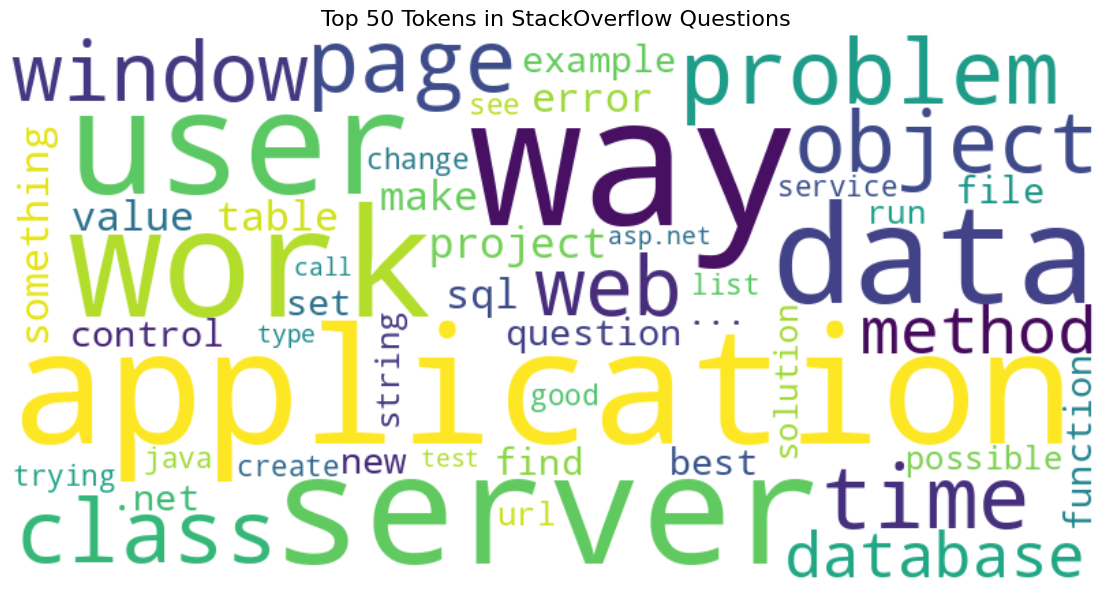

In [21]:
top_50_vocab = build_vocabulary(df_questions_final, top_n=50)
word_freq    = dict(zip(top_50_vocab["token"], top_50_vocab["frequency"]))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="viridis",
    max_words=50,
).generate_from_frequencies(word_freq)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Top 50 Tokens in StackOverflow Questions", fontsize=16)
plt.tight_layout()
plt.show()

In [23]:
out_cols  = ["Id", "Title", "Score", "cleaned_text", "token_count"]
available = [c for c in out_cols if c in df_questions_final.columns]
df_questions_final[available].to_csv("questions_cleaned.csv", index=False)
print("Saved → questions_cleaned.csv")

Saved → questions_cleaned.csv
